# 3. Modelos base

Este capítulo acompaña la tercera pestaña del dashboard. Allí se pueden mover el modelo, el conjunto de
datos y el umbral de decisión; aquí las figuras quedan fijas en los valores por defecto (conjunto de
prueba y umbral óptimo de cada modelo) y se explica qué dice cada una sobre la dificultad cognitiva
subjetiva (DCS).

Los dos modelos son lineales. El primero es la regresión logística del Entregable 1. El segundo es una
SVM lineal, que añadimos para tener una referencia distinta. El enunciado del proyecto habla de «SVR lineal»,
pero el SVR es la versión de regresión de la SVM y nuestra variable objetivo es binaria; para
clasificar corresponde la SVM lineal (`LinearSVC`). Como esta no entrega probabilidades, la envolvemos en
una calibración sigmoide (`CalibratedClassifierCV`) para poder comparar umbrales, curvas PR y
calibración en igualdad de condiciones con la logística.

In [1]:
from informe import *

LR, SV = "Regresión logística", "SVM lineal"
UMB = {m: A["umbral"][m]["umbral"] for m in (LR, SV)}
print({m: round(u, 3) for m, u in UMB.items()}, "| C logística:", A["lr_params"]["lr__C"], "| C SVM:", A["svm_C"])

{'Regresión logística': 0.246, 'SVM lineal': 0.24} | C logística: 1 | C SVM: 0.1


## 3.1 Cómo se entrenaron los modelos

Las dos máquinas comparten el mismo preprocesamiento, y vale la pena enumerarlo porque cada paso
responde a una característica de los datos que vimos en el capítulo 2.

In [2]:
pre = pd.DataFrame([
    ["Edad", "Splines cúbicos con 4 nodos + estandarización", "La prevalencia por edad no es una recta: baja hasta los 50 y sube después."],
    ["Variables categóricas", "One-hot (se omite la categoría de referencia)", "Los coeficientes se leen como odds ratios frente a la referencia."],
    ["Categorías con pocos casos", "Se agrupan en «Otro / múltiple» (menos del 1 %)", "Evita coeficientes inestables con decenas de personas."],
    ["Datos faltantes", "Indicador de «sin dato» por variable con faltantes", "Los faltantes no son aleatorios (capítulo 2); el indicador deja que el modelo los use."],
    ["Peso muestral", "No se usa en el entrenamiento", "Se busca predecir, no estimar prevalencias nacionales."],
], columns=["Elemento", "Tratamiento", "Por qué"])
ver(pre)

Elemento,Tratamiento,Por qué
Edad,Splines cúbicos con 4 nodos + estandarización,La prevalencia por edad no es una recta: baja hasta los 50 y sube después.
Variables categóricas,One-hot (se omite la categoría de referencia),Los coeficientes se leen como odds ratios frente a la referencia.
Categorías con pocos casos,Se agrupan en «Otro / múltiple» (menos del 1 %),Evita coeficientes inestables con decenas de personas.
Datos faltantes,Indicador de «sin dato» por variable con faltantes,Los faltantes no son aleatorios (capítulo 2); el indicador deja que el modelo los use.
Peso muestral,No se usa en el entrenamiento,"Se busca predecir, no estimar prevalencias nacionales."


El pipeline completo (preprocesamiento más modelo) se ajusta dentro de cada partición de la validación
cruzada, de manera que ninguna estadística calculada con los datos de validación se filtra a
la fase de entrenamiento. La búsqueda de hiperparámetros usa una validación cruzada estratificada de 5
particiones, con la PR-AUC como criterio, porque con una prevalencia del 20,6 % la ROC-AUC resulta
demasiado optimista y la exactitud engañosa.

El umbral de decisión no es 0,5. Se escoge el que maximiza la F1 sobre las predicciones *fuera de
muestra* del entrenamiento (las que cada persona recibe cuando su fila quedó en la partición de
validación), y recién entonces se aplica una sola vez al conjunto de prueba. Eso da 0,246 para la
logística y 0,240 para la SVM.

## 3.2 Resultados en el conjunto de prueba

### Indicadores principales

In [3]:
for m in (LR, SV):
    mt = A["metricas_test"][m]
    print(f"{m}: PR-AUC {mt['PR-AUC']:.3f} | ROC-AUC {mt['ROC-AUC']:.3f} | recall {mt['Recall']:.3f} | precisión {mt['Precisión']:.3f} | F1 {mt['F1']:.3f}")

Regresión logística: PR-AUC 0.538 | ROC-AUC 0.804 | recall 0.637 | precisión 0.461 | F1 0.535
SVM lineal: PR-AUC 0.537 | ROC-AUC 0.803 | recall 0.635 | precisión 0.463 | F1 0.536


Las tarjetas de la parte superior de la pestaña repiten estos indicadores para el modelo y el
umbral escogidos. Con la logística y su umbral óptimo, el modelo recupera a 64 de cada 100 personas que
dicen tener dificultad (recall de 0,637) y, de las que marca como positivas, 46 de cada 100 lo son en
verdad (precisión de 0,461). La SVM queda a una milésima en todo: 0,635 y 0,463.

La precisión puede parecer baja, pero hay que compararla con el 20,6 % de partida: el modelo
más que duplica la tasa de aciertos de quien eligiera personas al azar. Lo que no logra es separar
limpiamente los dos grupos, y eso es esperable porque la DCS es una percepción subjetiva con mucho
componente que ninguna de nuestras 14 variables observa.

### Matriz de confusión

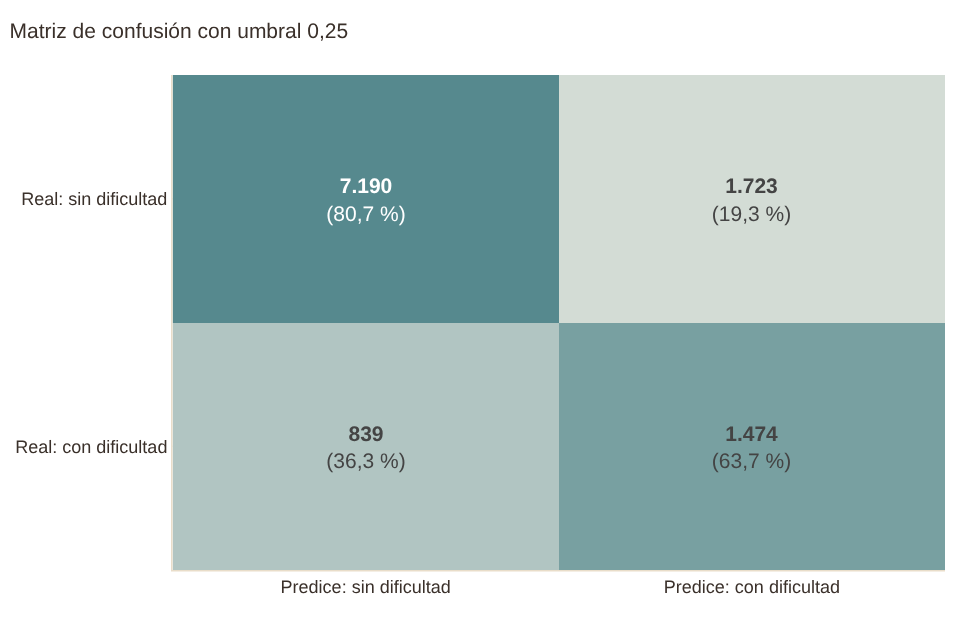

In [4]:
mostrar(F.fig_confusion(A["y_te"], A["p_te"][LR], UMB[LR]), ancho=640, alto=420)

La matriz muestra qué pasa con las 11.226 personas de prueba al aplicar el umbral. Cada celda trae el
conteo y el porcentaje de su fila, y las filas son la realidad: la de abajo recoge a quienes sí
reportan dificultad. La lectura útil está en las dos celdas fuera de la diagonal. Los falsos negativos
(personas con dificultad que el modelo deja pasar) son poco más de una de cada tres de las que
tienen DCS (839 de 2.313); los falsos positivos son personas que el modelo marca y que no reportan dificultad, y son más
numerosos que los verdaderos positivos porque el umbral es bajo a propósito.

Si se piensa en un tamizaje, tiene sentido que el umbral sacrifique precisión a cambio de recall:
perder un caso cuesta más que revisar a alguien que no lo necesitaba. Si en cambio se usara el modelo para
asignar un recurso escaso, convendría subir el umbral. El control deslizante del dashboard sirve
justamente para ver esa disyuntiva.

### Curvas ROC y de precisión-recall

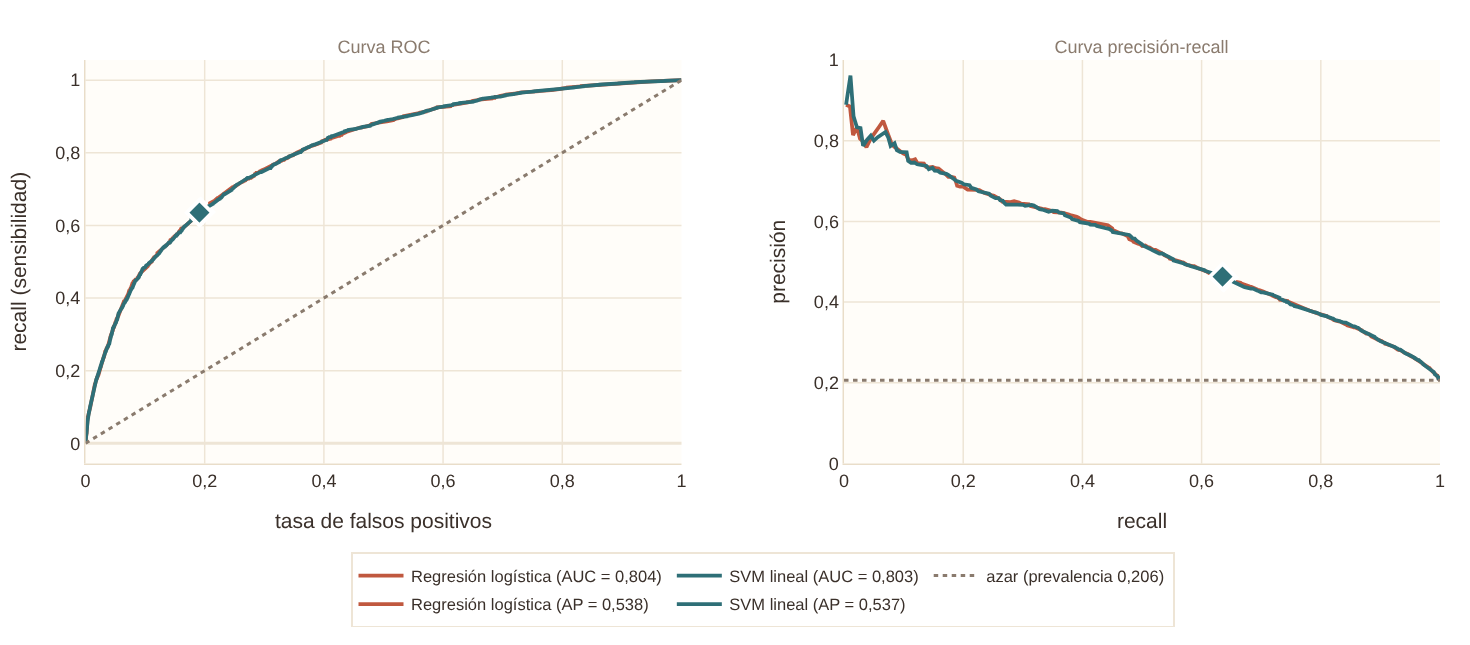

In [5]:
mostrar(F.fig_roc_pr(A, [LR, SV], "prueba", UMB), alto=430)

A la izquierda está la curva ROC y a la derecha la de precisión-recall, con los dos modelos y la línea
de referencia del clasificador trivial. Las dos curvas de los modelos prácticamente se superponen: ni
en la zona de alta precisión ni en la de alto recall hay un punto donde una máquina supere a la otra de
forma visible. El rombo marca el umbral operativo de cada una.

La curva PR es la más reveladora para este problema. Parte cerca de una precisión de 0,8 con recalls muy
bajos, es decir, que las personas a las que el modelo les asigna las probabilidades más altas casi siempre
tienen DCS, y desciende de forma gradual hasta acercarse al 0,206 de la línea base cuando se exige
encontrar a todos los casos. El ROC-AUC de 0,804 se interpreta como la probabilidad de que, tomando al azar
una persona con DCS y una sin ella, el modelo asigne la probabilidad mayor a la primera.

### Distribución de las probabilidades

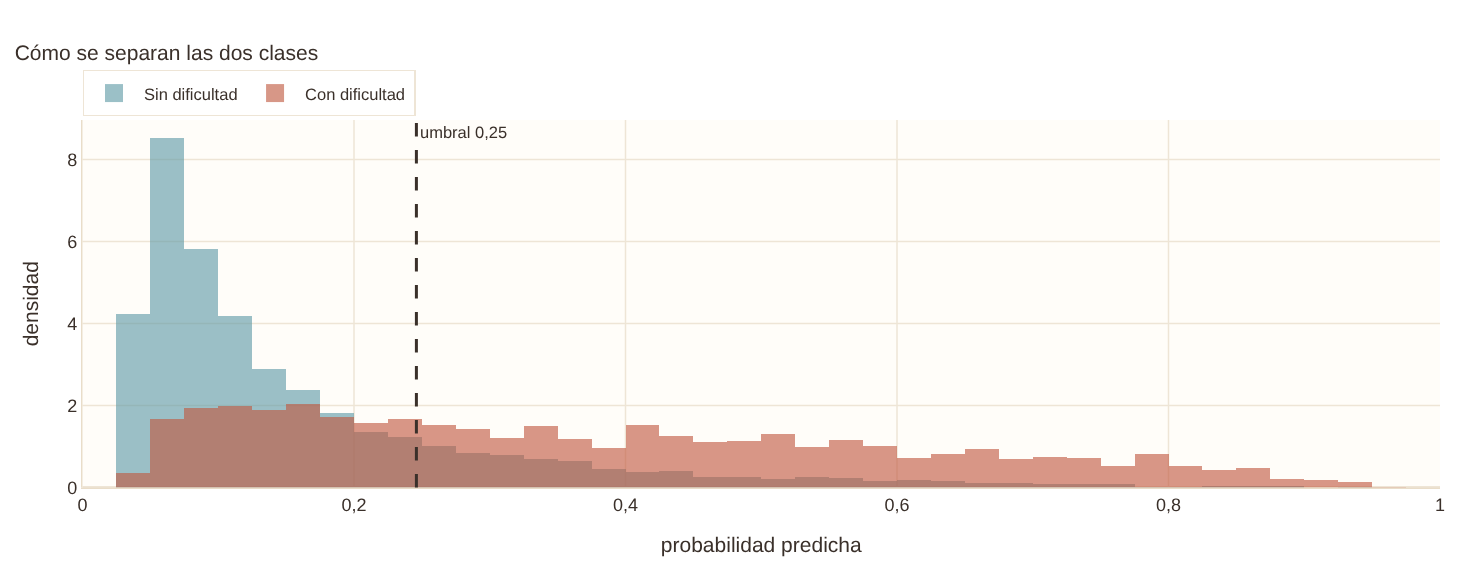

In [6]:
mostrar(F.fig_hist_prob(A["y_te"], A["p_te"][LR], UMB[LR]), alto=380)

El histograma separa las probabilidades predichas según la realidad. Las personas sin DCS se
agrupan a la izquierda, con la mayor parte por debajo de 0,2, mientras que las que sí la tienen forman una
distribución más ancha que se extiende hacia la derecha. Las dos distribuciones se solapan en la zona
de 0,15 a 0,4, y es justo ahí donde cae el umbral. Ese solapamiento es la imagen del techo del modelo: hay
personas con un perfil de riesgo idéntico en las 14 variables, algunas con DCS y otras sin ella.

### Barrido del umbral

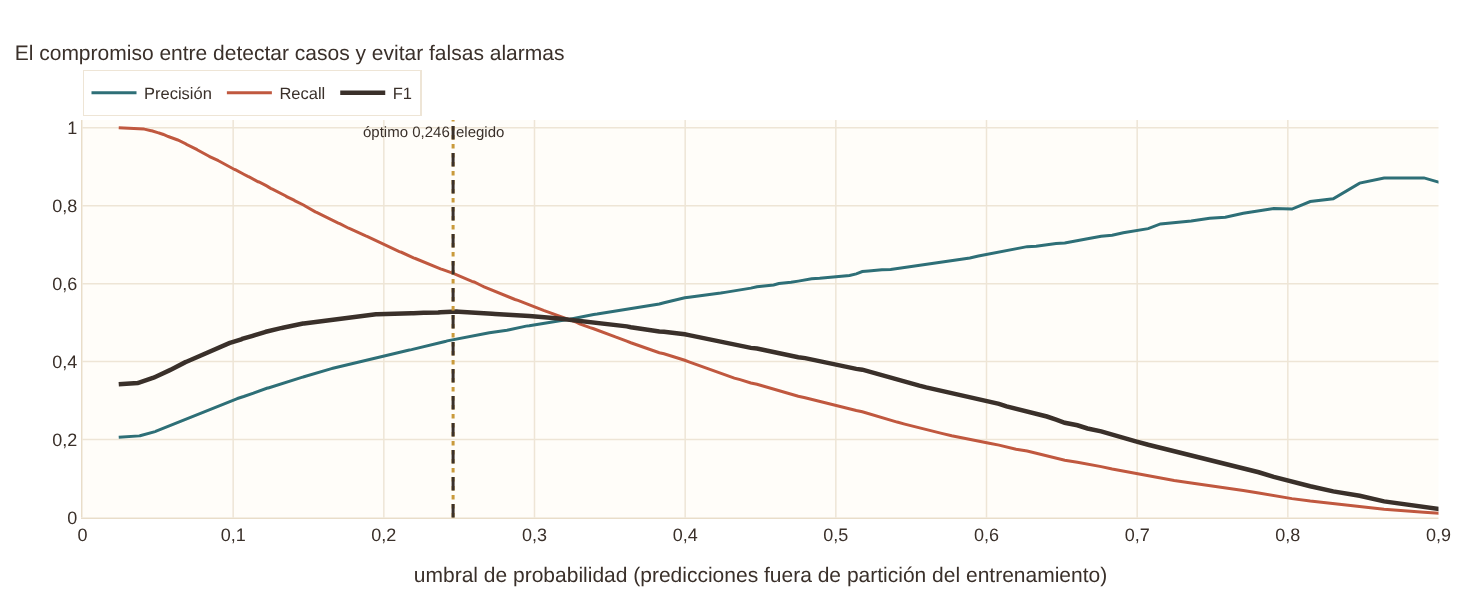

umbral,recall,precisión,F1
0.150,0.805,0.368,0.505
0.246,0.637,0.461,0.535
0.350,0.488,0.548,0.516
0.500,0.309,0.643,0.417


In [7]:
mostrar(F.fig_barrido_umbral(A, LR, UMB[LR]), alto=400)

# Tabla con cuatro umbrales de referencia (la figura permite leer cualquier otro)
filas = []
for u in (0.15, UMB[LR], 0.35, 0.50):
    mm = F.metricas_umbral(A["y_te"], A["p_te"][LR], u)
    filas.append({"umbral": u, "recall": mm["Recall"], "precisión": mm["Precisión"], "F1": mm["F1"]})
ver(pd.DataFrame(filas), {"umbral": "{:.3f}", "recall": "{:.3f}", "precisión": "{:.3f}", "F1": "{:.3f}"})

El barrido muestra cómo se mueven el recall, la precisión y la F1 cuando cambia el umbral. El recall
cae de forma constante a medida que se exige más seguridad y la precisión sube, aunque con
menos velocidad. La F1 es una curva con un máximo amplio, de modo que moverse un poco alrededor del
punto óptimo cambia poco el resultado.

La tabla lo concreta. Con 0,15 el modelo encuentra a ocho de cada diez personas con DCS (recall de
0,805), pero apenas el 37 % de sus alertas son correctas. Con 0,5, la regla que se usa por defecto, la
precisión sube a 0,643 y el recall se hunde a 0,309: se pasarían por alto dos de cada tres casos. El umbral
de 0,246 es un punto intermedio con una F1 de 0,535, y es una decisión que depende del uso, no una verdad
del modelo.

## 3.3 Comparación entre modelos y calibración

### Comparación con el clasificador trivial

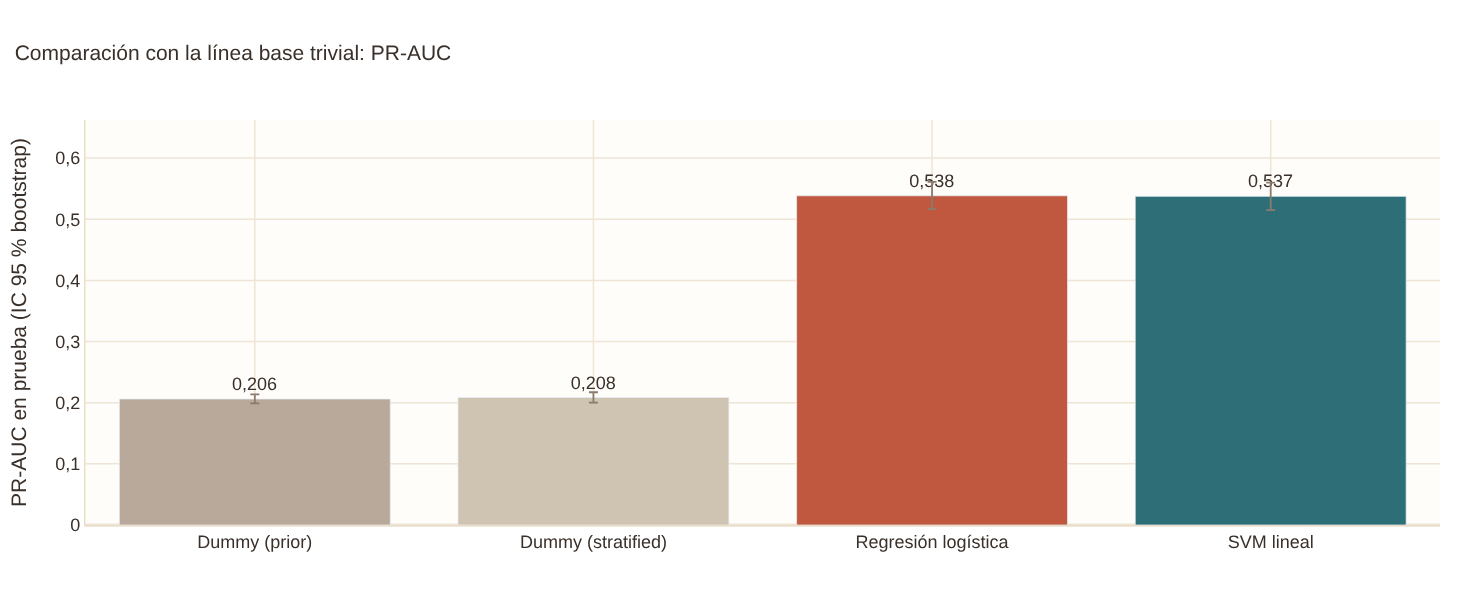

Modelo,PR-AUC,ROC-AUC,Recall,Precisión,F1,Balanced acc.,Brier,Accuracy
Dummy (prior),"0,206 [0,199–0,214]","0,500 [0,500–0,500]","0,000 [0,000–0,000]","0,000 [0,000–0,000]","0,000 [0,000–0,000]","0,500 [0,500–0,500]","0,164 [0,159–0,168]","0,794 [0,786–0,801]"
Dummy (stratified),"0,208 [0,200–0,217]","0,507 [0,497–0,517]","0,214 [0,197–0,234]","0,217 [0,199–0,237]","0,216 [0,199–0,234]","0,507 [0,497–0,517]","0,321 [0,313–0,330]","0,679 [0,670–0,687]"
Regresión logística,"0,538 [0,517–0,561]","0,804 [0,794–0,814]","0,637 [0,619–0,657]","0,461 [0,445–0,480]","0,535 [0,520–0,552]","0,722 [0,712–0,733]","0,128 [0,124–0,132]","0,772 [0,764–0,780]"
SVM lineal,"0,537 [0,515–0,560]","0,803 [0,794–0,813]","0,635 [0,618–0,656]","0,463 [0,447–0,481]","0,536 [0,521–0,552]","0,722 [0,712–0,733]","0,128 [0,124–0,132]","0,773 [0,766–0,781]"


In [8]:
mostrar(F.fig_comparacion(A, "PR-AUC"), alto=400)
ver(F.tabla_metricas(A))

Las barras comparan los cuatro modelos en la métrica que se elija en el desplegable (aquí PR-AUC), con
su intervalo del 95 % obtenido por bootstrap con 1.000 remuestreos del conjunto de prueba. Los dos
clasificadores triviales sirven para saber qué significa «cero información»: el que siempre dice «no»
(Dummy prior) tiene una PR-AUC de 0,206, igual a la prevalencia, y el que sortea según la proporción de
clases (Dummy stratified) queda en 0,208.

Frente a ellos, los dos modelos suben a 0,538 y 0,537, y los intervalos no se tocan con los de los
triviales. La diferencia es de 0,33 en PR-AUC y no es un asunto de azar de la muestra de prueba.
En el Brier, que mide el error de las probabilidades, la logística y la SVM alcanzan 0,128 frente
a 0,164 del trivial, lo que equivale a una mejora relativa («Brier skill») de 0,219 y 0,217.

### ¿Hay diferencias entre la logística y la SVM?

In [9]:
b = A["boot"]
dif = b[LR] - b[SV]
filas = []
for met in ("PR-AUC", "ROC-AUC", "Recall", "Precisión", "F1", "Brier"):
    d = dif[met]
    filas.append({"métrica": met, "diferencia media (LR − SVM)": d.mean(), "IC 95 % inferior": d.quantile(.025), "IC 95 % superior": d.quantile(.975),
                  "¿incluye el 0?": "sí" if d.quantile(.025) <= 0 <= d.quantile(.975) else "no"})
ver(pd.DataFrame(filas), {c: "{:+.4f}" for c in ["diferencia media (LR − SVM)", "IC 95 % inferior", "IC 95 % superior"]})

pl, ps = A["p_te"][LR], A["p_te"][SV]
yl, ys = pl >= UMB[LR], ps >= UMB[SV]
print(f"Correlación entre las probabilidades de ambos modelos: {np.corrcoef(pl, ps)[0, 1]:.3f}")
print(f"Coinciden en la clasificación del {(yl == ys).mean():.1%} de las personas de prueba")

métrica,diferencia media (LR − SVM),IC 95 % inferior,IC 95 % superior,¿incluye el 0?
PR-AUC,+0.0009,-0.0018,+0.0037,sí
ROC-AUC,+0.0003,-0.0008,+0.0014,sí
Recall,+0.0022,-0.0044,+0.0086,sí
Precisión,-0.0017,-0.0064,+0.0028,sí
F1,-0.0004,-0.0052,+0.0044,sí
Brier,-0.0004,-0.0007,-0.0000,no


Correlación entre las probabilidades de ambos modelos: 0.994
Coinciden en la clasificación del 97.8% de las personas de prueba


Esta tabla no aparece en el dashboard. Como los dos modelos se evaluaron sobre los mismos
remuestreos bootstrap, la diferencia entre ellos se puede calcular remuestreo a remuestreo, y esa es una
comparación más fina que mirar si los intervalos individuales se solapan. En la PR-AUC la diferencia es de
unas milésimas y su intervalo incluye el cero; con las demás métricas pasa lo mismo, con una excepción
en el Brier, donde la logística es unas diezmilésimas mejor (menor) y el intervalo no incluye el cero; es una ventaja real pero
demasiado pequeña para tener consecuencias prácticas.

Los dos modelos, además, producen casi las mismas probabilidades (correlación de 0,994) y toman la misma
decisión para el 97,8 % de las personas. Tiene sentido: ambos son lineales sobre el mismo conjunto de
variables transformadas, y lo único que cambia es la función de pérdida con que se ajustan los
coeficientes. Concluimos que, para estos datos, la elección entre una y otra no pesa, y que se prefiere
la logística por una razón práctica: sus coeficientes tienen una lectura directa como odds ratios.

### Calibración

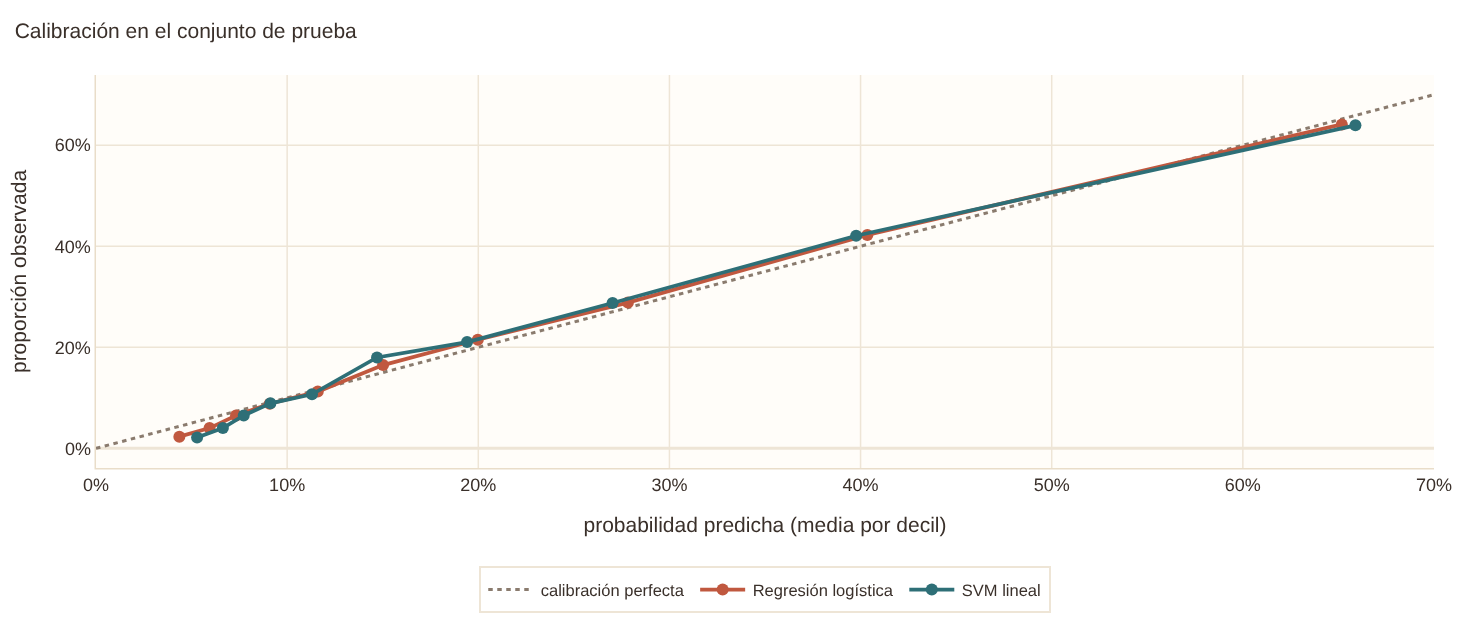

In [10]:
mostrar(F.fig_calibracion(A, [LR, SV]), alto=420)

La curva de calibración agrupa a las personas de prueba en diez grupos según la probabilidad que el
modelo les asignó y compara esa probabilidad con la frecuencia real de DCS en cada grupo. Si el modelo
estuviera perfectamente calibrado, los puntos caerían sobre la diagonal. Los dos modelos quedan muy cerca
de ella en casi todo el rango: por ejemplo, el grupo al que la logística le asigna un 20 % promedio tiene
en realidad un 21,5 %, y el de 40 % tiene un 42 %.

La excepción está en los extremos. En el grupo de menor riesgo, el modelo predice 4,4 % y en la realidad
es 2,3 %: sobrestima el riesgo de quienes están mejor. Esto interesa si las probabilidades se van a
presentar como tales (como lo hace el simulador), porque en ese tramo el modelo es algo pesimista. Para
ordenar a las personas por riesgo no representa ningún problema.

## 3.4 Hiperparámetros y tamaño de la muestra

### Búsqueda en rejilla

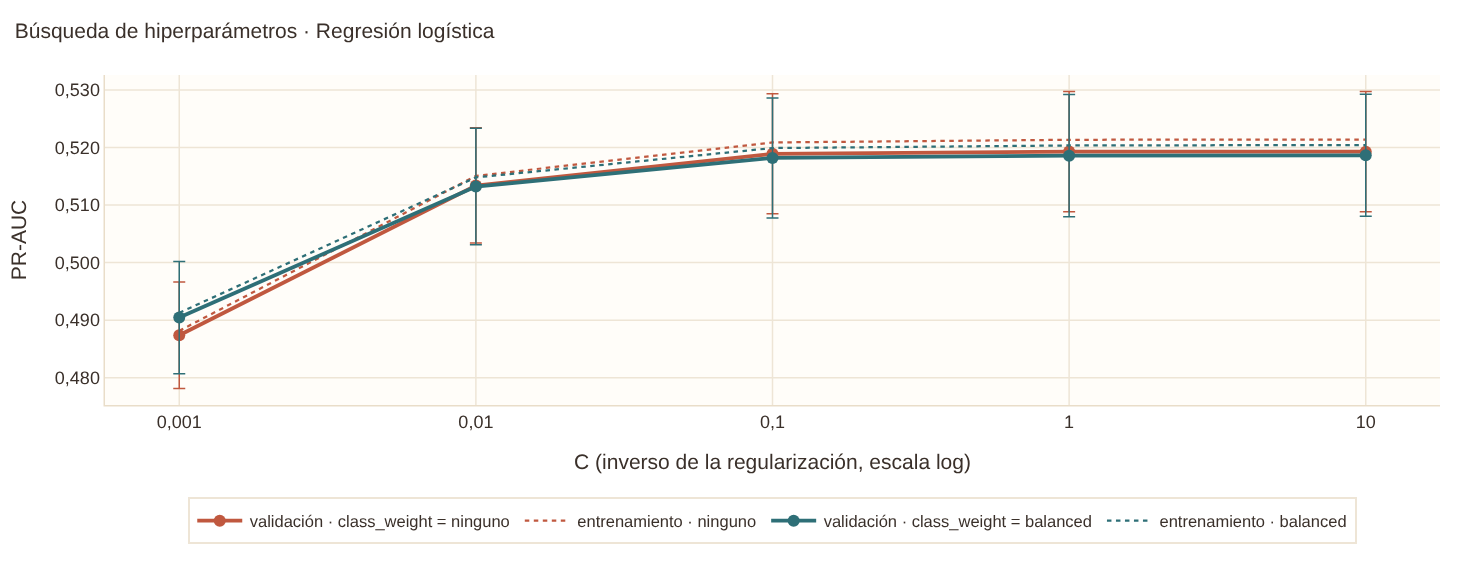

C,class_weight,PR-AUC (val.),de PR-AUC,PR-AUC (entr.),ROC-AUC (val.),Brier (val.)
1.000000,ninguno,0.519,0.010,0.521,0.793,0.131
10.000000,ninguno,0.519,0.010,0.521,0.793,0.131
0.100000,ninguno,0.519,0.010,0.521,0.793,0.131
10.000000,balanced,0.519,0.011,0.520,0.793,0.183
1.000000,balanced,0.519,0.011,0.520,0.793,0.183
0.100000,balanced,0.518,0.010,0.520,0.793,0.183


C,PR-AUC (val.),de PR-AUC,PR-AUC (entr.),ROC-AUC (val.)
0.100000,0.5201,0.0098,0.5219,0.7935
1.000000,0.5201,0.0099,0.5219,0.7935
0.010000,0.5201,0.0098,0.5216,0.7934
0.001000,0.5153,0.0094,0.5170,0.7907


In [11]:
mostrar(F.fig_grid(A, LR), alto=380)
g = A["grid_lr"].copy()
ver(g.head(6), {c: "{:.3f}" for c in g.columns if c not in ("C", "class_weight")})
ver(A["grid_svm"], {c: "{:.4f}" for c in A["grid_svm"].columns if c != "C"})

La rejilla de la logística combinó cinco valores de C (la fuerza de la regularización, donde C
pequeño significa más penalización) con dos opciones de pesos de clase: sin ponderar o `balanced`. Lo que
se ve en el gráfico y en la tabla es una meseta. Entre C = 0,1 y C = 10 la PR-AUC de validación
no cambia de la tercera cifra decimal (0,519), y solo cae con regularizaciones muy fuertes (C ≤ 0,01), que
empiezan a aplanar los coeficientes. La diferencia entre los dos primeros puestos es de 0,000014, mucho menor
que la desviación entre particiones (0,010). Por eso se escogió C = 1: no por ser mejor, sino porque entre
empates se elige la opción intermedia.

Los pesos de clase `balanced` no mejoran la PR-AUC ni la ROC-AUC, pero sí empeoran el Brier (0,183 frente
a 0,131), porque desplazan todas las probabilidades hacia arriba. Como el modelo se debe poder
interpretar como probabilidad y el umbral ya se ajusta aparte, la decisión es no ponderar.

La SVM muestra el mismo patrón: C = 0,01, 0,1 y 1 empatan en una PR-AUC de 0,520, y solo C = 0,001 queda
algo por debajo. Se tomó C = 0,1, el empate del medio.

### Curva de aprendizaje

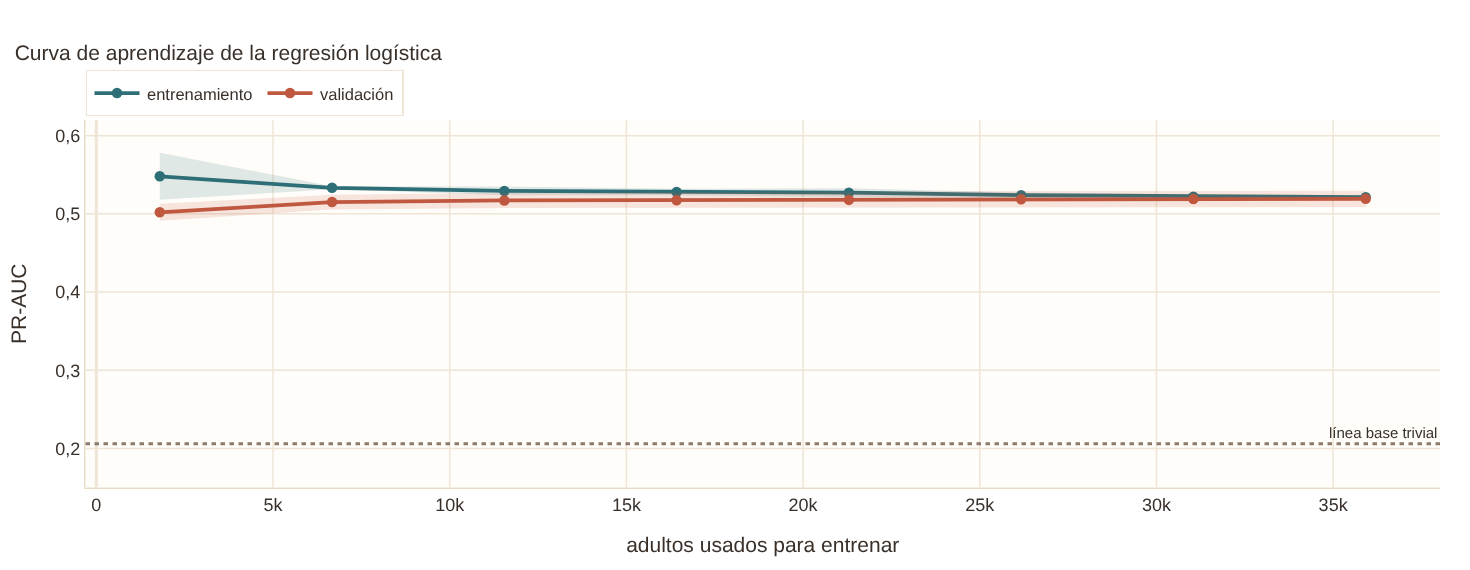

n,train,train_sd,val,val_sd,brecha
"1,796",0.548,0.030,0.502,0.011,0.046
"6,671",0.533,0.002,0.515,0.009,0.018
"11,546",0.529,0.006,0.517,0.010,0.012
"16,421",0.528,0.004,0.517,0.010,0.011
"21,296",0.527,0.006,0.518,0.011,0.009
"26,171",0.524,0.003,0.519,0.011,0.005
"31,046",0.522,0.003,0.519,0.010,0.003
"35,922",0.521,0.002,0.519,0.010,0.002


In [12]:
mostrar(F.fig_curva_aprendizaje(A), alto=380)
ca = A["curva_aprendizaje"].copy()
ca["brecha"] = ca["train"] - ca["val"]
ver(ca, {"n": "{:,.0f}", "train": "{:.3f}", "train_sd": "{:.3f}", "val": "{:.3f}", "val_sd": "{:.3f}", "brecha": "{:.3f}"})

La curva muestra la PR-AUC en el entrenamiento y en la validación cuando el modelo aprende con una fracción
creciente de los datos. Con unos 1.800 adultos hay una brecha de 0,046 entre ambas, que es el síntoma de
sobreajuste. A partir de ahí la curva de entrenamiento baja y la de validación sube, y con la muestra completa (unos
36.000 adultos en cada partición de entrenamiento) la brecha es de 0,002. Las dos líneas se juntan
en 0,52.

Dos cosas se desprenden. Primero, el modelo no sobreajusta: tiene pocos parámetros para tantos datos.
Segundo, la validación ya es casi plana desde los 20.000 adultos; conseguir más datos *de este tipo* no
subiría mucho la PR-AUC. Si queremos mejorar hay que añadir información nueva (más variables, o relaciones
no lineales entre las existentes), no más filas.

## 3.5 Interpretación: qué factores pesan

### Odds ratios del modelo logístico

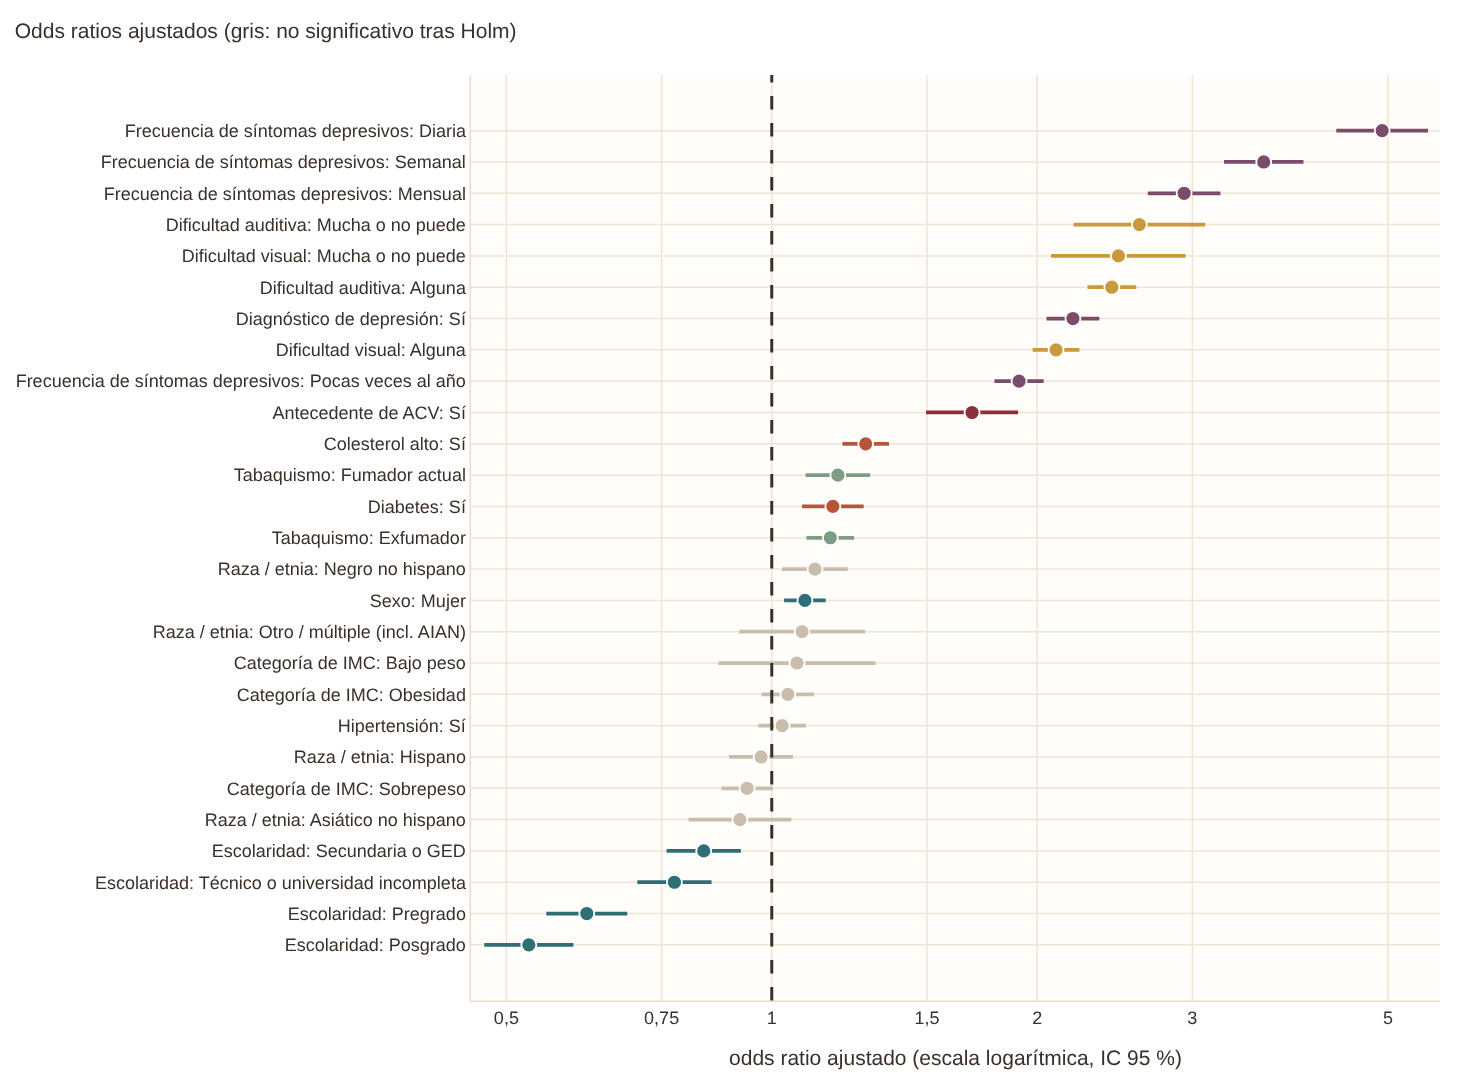

etiqueta,OR,ic_inf,ic_sup,p_holm
Frecuencia de síntomas depresivos: Diaria,4.93,4.37,5.55,0.000
Frecuencia de síntomas depresivos: Semanal,3.61,3.26,4.01,0.000
Frecuencia de síntomas depresivos: Mensual,2.94,2.67,3.23,0.000
Dificultad auditiva: Mucha o no puede,2.61,2.20,3.10,0.000
Dificultad visual: Mucha o no puede,2.47,2.07,2.95,0.000
Dificultad auditiva: Alguna,2.43,2.28,2.59,0.000
Diagnóstico de depresión: Sí,2.20,2.05,2.35,0.000
Dificultad visual: Alguna,2.10,1.98,2.23,0.000
Frecuencia de síntomas depresivos: Pocas veces al año,1.91,1.79,2.03,0.000
Antecedente de ACV: Sí,1.69,1.50,1.90,0.000


In [13]:
mostrar(F.fig_or(A), alto=720)
t = A["or"][["etiqueta", "OR", "ic_inf", "ic_sup", "p_holm"]].copy()
ver(t.sort_values("OR", ascending=False), {"OR": "{:.2f}", "ic_inf": "{:.2f}", "ic_sup": "{:.2f}", "p_holm": "{:.3f}"})

El bosque de odds ratios es la lectura clínica del modelo. Cada punto indica cuánto se multiplican las
probabilidades de reportar DCS (las odds) cuando una persona tiene esa característica frente a la
categoría de referencia, manteniendo constantes las demás variables; la barra es su intervalo del 95 %.
La línea de OR = 1 marca la ausencia de efecto, y el dashboard permite filtrar por bloque temático y quedarse
solo con los efectos significativos tras la corrección de Holm. Las cifras vienen de un modelo de
`statsmodels` ajustado sobre los mismos datos transformados, y sus coeficientes coinciden con los del
modelo de scikit-learn (correlación de 0,998).

El orden de los factores es lo más informativo:

- **La salud mental domina.** La frecuencia de los síntomas depresivos tiene el gradiente más claro de todo
  el modelo: respecto a quienes nunca los sienten, el OR es de 1,9 si ocurren pocas veces al año, 2,9 si son
  mensuales, 3,6 si son semanales y 4,9 si son diarios. El diagnóstico de depresión suma un OR adicional de 2,2.
  Se trata de dos variables que miden cosas cercanas y por eso el efecto se reparte entre ambas, pero juntas
  sitúan a la depresión como la señal más fuerte. Esto es coherente con la literatura, que describe la queja
  cognitiva y la depresión como entrelazadas, y también con la advertencia de que parte de la DCS
  puede ser un síntoma del estado de ánimo y no un indicio de deterioro cognitivo.
- **Los sentidos le siguen.** La dificultad auditiva tiene OR de 2,4 (alguna) y 2,6 (mucha o no puede), y la
  visual de 2,1 y 2,5. Son factores de riesgo reconocidos por Lancet, y aquí además tienen una
  explicación directa: a quien oye o ve mal le cuesta más seguir una conversación o leer, y lo vive como
  falta de atención.
- **El ACV** tiene un OR de 1,69 [1,50-1,90], un efecto claro pero de menor tamaño que los anteriores, porque
  es poco frecuente (alrededor de 3,5 % de los adultos) y porque parte de su efecto lo recogen la
  edad y la depresión post-ACV.
- **Los factores cardiometabólicos** son modestos. El colesterol alto (1,28) y la diabetes (1,17) son
  significativos, y la hipertensión (1,03 [0,97-1,09]) y las categorías de IMC no lo son. El primer entregable mostraba
  que la hipertensión *parece* un factor fuerte en las comparaciones simples (OR crudo de 1,8); lo que
  vemos ahora es que, una vez se ajusta por edad y depresión, casi todo ese efecto desaparece. Es un
  ejemplo de confusión.
- **La escolaridad protege, y con gradiente.** Frente a quienes no terminaron secundaria, el OR baja a 0,84
  con secundaria, 0,78 con estudios técnicos, 0,62 con pregrado y 0,53 con posgrado. Es la lectura habitual de la
  reserva cognitiva, aunque aquí también podría reflejar que las personas con más estudios reportan menos
  quejas por razones culturales.
- **El tabaquismo** presenta OR de 1,17 (exfumadores) y 1,19 (fumadores actuales), efectos pequeños pero
  consistentes.
- **Sexo y raza o etnia.** Las mujeres tienen un OR de 1,09 y los adultos negros no hispanos de 1,12, aunque
  este último no sobrevive a la corrección de Holm (p ajustado = 0,08). Los demás grupos étnicos no se separan de la
  referencia.

Una precaución sobre la lectura: son asociaciones transversales. Que un factor tenga un OR alto significa
que ayuda a *predecir* la DCS, no que la cause.

### Efecto de la edad

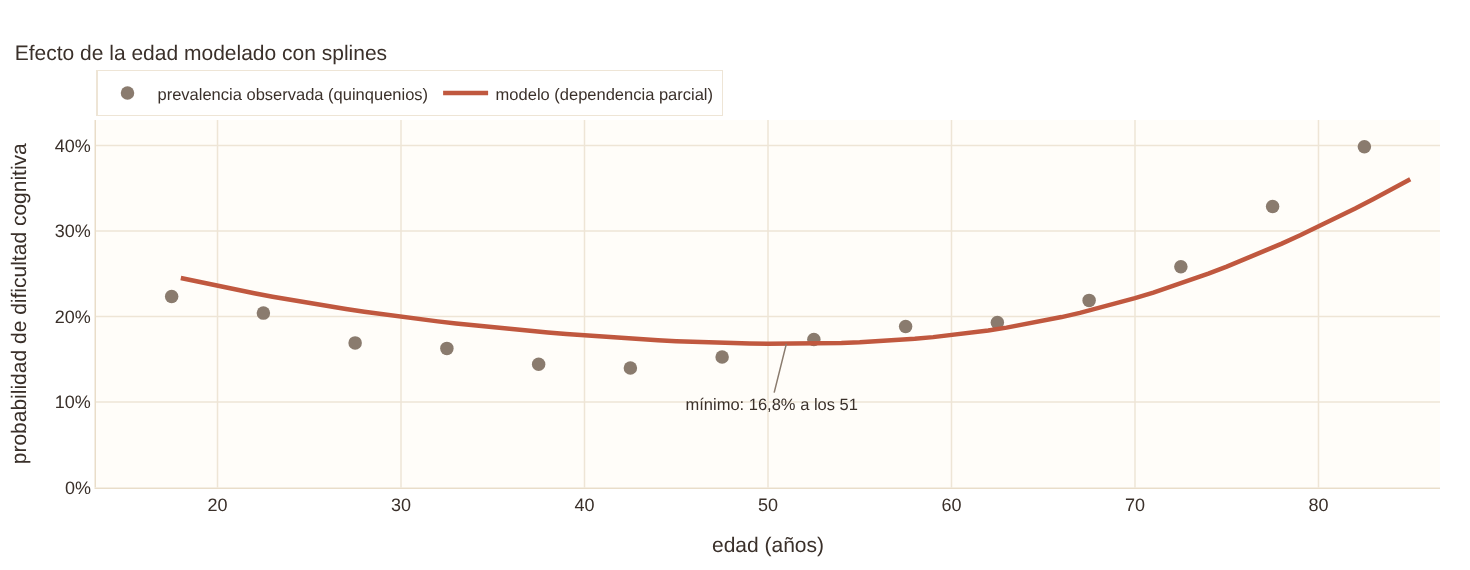

edad,probabilidad
18,0.245
30,0.200
40,0.178
51,0.168
60,0.178
70,0.221
85,0.361


In [14]:
mostrar(F.fig_dep_edad(A), alto=380)
de = A["dep_edad"].set_index("edad")["prob"]
ver(pd.DataFrame({"edad": [18, 30, 40, 51, 60, 70, 85], "probabilidad": [de.loc[e] for e in (18, 30, 40, 51, 60, 70, 85)]}), {"probabilidad": "{:.3f}"})

La edad entra al modelo mediante splines, así que no tiene un solo coeficiente. Este gráfico de dependencia
parcial muestra la probabilidad promedio que predice el modelo al fijar la edad de todas las
personas y dejar el resto como está. Describe una curva en U: la probabilidad parte de 0,245 a los
18 años, desciende hasta un mínimo de 0,168 hacia los 51 y vuelve a subir hasta 0,361 a los 85.

La parte descendente sorprende y no es un error. Los adultos jóvenes reportan dificultades de concentración
con frecuencia (por estrés, sueño, ansiedad), cosa que ya se veía en los datos crudos del capítulo 2, y el
modelo lo captura con la forma flexible de la spline. Un modelo con la edad como una recta habría
tratado a una persona de 20 años como de bajo riesgo y se habría equivocado con ese grupo.

### Una interacción que el dashboard no explora: ACV por edad

In [15]:
import statsmodels.formula.api as smf

d = TRAIN.copy()
d["acv_n"] = (d["acv"] == "Sí").astype(int)
d["edad_c"] = (d["edad"] - 50) / 10                  # edad centrada, por décadas
cov = " + ".join(f"C({v})" for v in PREDICTORAS_CAT if v != "acv")

filas = []
for nombre, extra in [("Sin ajustar (solo ACV y edad)", ""), ("Ajustado por las demás variables", " + " + cov)]:
    m0 = smf.logit(f"{OBJETIVO} ~ acv_n + edad_c{extra}", d).fit(disp=0)
    m1 = smf.logit(f"{OBJETIVO} ~ acv_n * edad_c{extra}", d).fit(disp=0)
    fila = {"modelo": nombre, "coef. interacción": m1.params["acv_n:edad_c"], "p": m1.pvalues["acv_n:edad_c"]}
    for e in (30, 50, 70, 85):
        fila[f"OR ACV a {e} años"] = np.exp(m1.params["acv_n"] + m1.params["acv_n:edad_c"] * (e - 50) / 10)
    filas.append(fila)
ver(pd.DataFrame(filas), {"coef. interacción": "{:+.3f}", "p": "{:.3f}", **{c: "{:.2f}" for c in ["OR ACV a 30 años", "OR ACV a 50 años", "OR ACV a 70 años", "OR ACV a 85 años"]}})

modelo,coef. interacción,p,OR ACV a 30 años,OR ACV a 50 años,OR ACV a 70 años,OR ACV a 85 años
Sin ajustar (solo ACV y edad),-0.130,0.001,4.44,3.42,2.64,2.17
Ajustado por las demás variables,-0.031,0.518,2.05,1.92,1.81,1.72


El objetivo específico 4 pide prestar atención al ACV, y en el capítulo 2 vimos que su OR crudo disminuye con la
edad. Aquí comprobamos si esa caída es real o la producen otras variables. La primera fila ajusta solo por la edad: el ACV
multiplica las odds por 4,4 a los 30 años y por 2,2 a los 85, y la interacción es significativa (p = 0,001).
La segunda fila añade el resto de las variables del modelo y el patrón se aplana: el OR va de 2,0 a 1,7 y la
interacción deja de ser significativa (p = 0,52).

Por lo tanto, la caída del efecto del ACV con la edad se explica casi del todo por las demás características,
sobre todo la depresión y los problemas sensoriales, que se acumulan en las personas mayores con ACV. En
otras palabras, el ACV no «pesa menos» en la vejez; lo que ocurre es que los mayores sin ACV ya tienen
muchos otros motivos para reportar dificultad. Un hallazgo así no es posible sacarlo del dashboard, y por eso lo
dejamos aquí como análisis complementario.

## 3.6 ¿Para quién funciona mejor el modelo?

### Diagnóstico por subgrupos

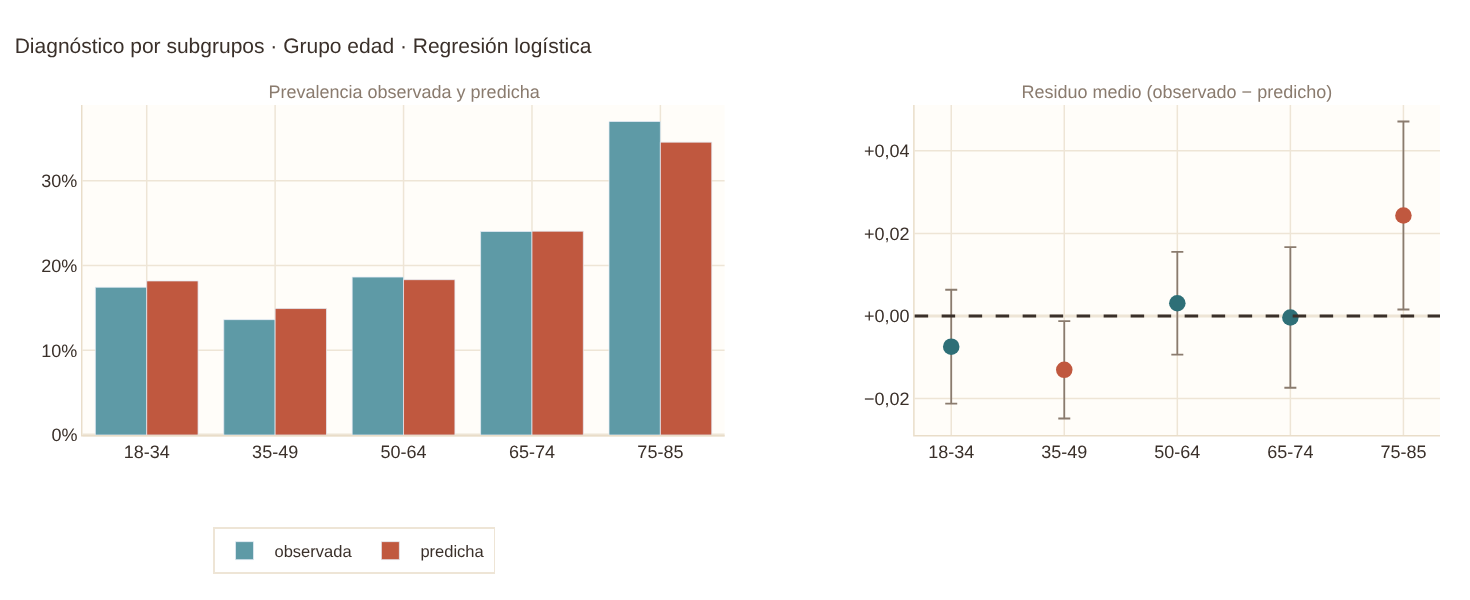

variable,nivel,n,observado,predicho,residuo,roc_auc,pr_auc
sexo,Hombre,"5,104",0.180,0.184,-0.005,0.800,0.495
sexo,Mujer,"6,121",0.228,0.225,+0.003,0.803,0.565
grupo_edad,18-34,"2,307",0.174,0.182,-0.007,0.800,0.506
grupo_edad,35-49,"2,528",0.136,0.149,-0.013,0.817,0.485
grupo_edad,50-64,"2,840",0.186,0.183,+0.003,0.819,0.561
grupo_edad,65-74,"2,075",0.240,0.240,-0.000,0.744,0.495
grupo_edad,75-85,"1,455",0.370,0.345,+0.024,0.733,0.621
acv,No,"10,795",0.196,0.198,-0.002,0.801,0.524
acv,Sí,419,0.463,0.441,+0.022,0.707,0.670
depresion_dx,No,"9,069",0.147,0.150,-0.003,0.772,0.406


In [16]:
mostrar(F.fig_subgrupos(A, LR, "grupo_edad"), alto=400)
sg = A["subgrupos"][LR]
ver(sg[sg["variable"].isin(["sexo", "grupo_edad", "acv", "depresion_dx"])][["variable", "nivel", "n", "observado", "predicho", "residuo", "roc_auc", "pr_auc"]],
    {"n": "{:,.0f}", "observado": "{:.3f}", "predicho": "{:.3f}", "residuo": "{:+.3f}", "roc_auc": "{:.3f}", "pr_auc": "{:.3f}"})

Esta sección responde si el modelo rinde parecido en todos los grupos. El dashboard permite escoger la variable
y el modelo; el gráfico de la izquierda pone lado a lado la prevalencia observada y la predicha de cada subgrupo,
y el de la derecha el residuo (observado menos predicho) con su intervalo.

Lo primero es que el modelo está bien calibrado dentro de casi todos los grupos: por sexo (hombres 18,0 % observado
y 18,4 % predicho; mujeres 22,8 % y 22,5 %), por año y por trimestre, los residuos son de alrededor de un punto porcentual o menos. El mayor
desvío por edad ocurre a los 35-49 años, donde se predice 14,9 % y la realidad es 13,6 %. A los 75-85 años el
modelo se queda corto en 2,4 puntos (34,5 % frente a 37,0 %).

Lo segundo, y más importante, es que la calibración no equivale a poder discriminar. El ROC-AUC es
de 0,82 en los adultos de 35 a 64 años y baja a 0,74 en los de 65-74 y a 0,73 en los de 75-85. En las
personas mayores casi todas tienen algo (hipertensión, problemas auditivos, depresión) y por tanto
el modelo tiene menos variables con que distinguir a quienes sí reportan dificultad de quienes no. Con quienes ya
tuvieron un ACV pasa algo similar (ROC-AUC de 0,71) y con quienes tienen diagnóstico de depresión (0,71): en
estos grupos todos tienen un riesgo alto y el modelo discrimina menos dentro de ellos.

Los grupos pequeños (indígenas americanos y de Alaska, con 71 y 75 personas) tienen intervalos amplios y no
permiten sacar conclusiones, aunque la prevalencia observada (32-37 %) es mayor que la del resto. Por eso
las dejamos señaladas para el análisis de equidad del siguiente entregable.

## 3.7 Simulador de riesgo

### Tres perfiles de ejemplo

perfil,probabilidad estimada,umbral,¿supera el umbral?
Bajo riesgo,3.9%,0.246,no
Riesgo medio,21.0%,0.246,no
Riesgo alto,91.0%,0.246,sí


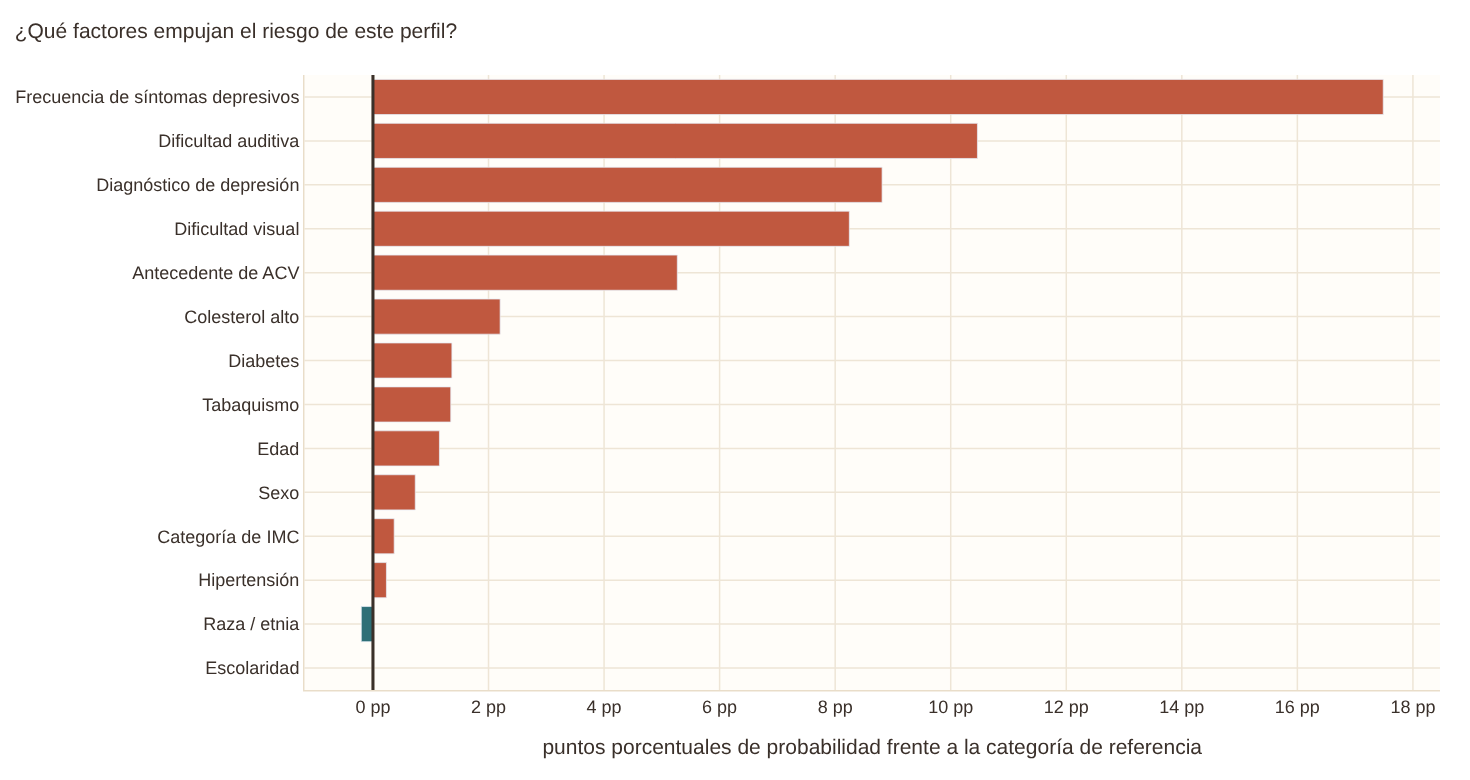

In [17]:
PERFILES = {
    "Bajo riesgo": dict(edad=35, sexo="Hombre", raza_etnia="Blanco no hispano", educacion="Posgrado", hipertension="No", colesterol_alto="No", diabetes="No",
                        acv="No", depresion_dx="No", frecuencia_depresion="Nunca", dificultad_auditiva="Ninguna", dificultad_visual="Ninguna",
                        tabaquismo="Nunca fumó", imc_categoria="Normal"),
    "Riesgo medio": dict(edad=55, sexo="Mujer", raza_etnia="Hispano", educacion="Secundaria o GED", hipertension="Sí", colesterol_alto="No", diabetes="No",
                         acv="No", depresion_dx="No", frecuencia_depresion="Pocas veces al año", dificultad_auditiva="Ninguna", dificultad_visual="Alguna",
                         tabaquismo="Exfumador", imc_categoria="Sobrepeso"),
    "Riesgo alto": dict(edad=62, sexo="Mujer", raza_etnia="Hispano", educacion="Menos que secundaria", hipertension="Sí", colesterol_alto="Sí", diabetes="Sí",
                        acv="Sí", depresion_dx="Sí", frecuencia_depresion="Semanal", dificultad_auditiva="Alguna", dificultad_visual="Alguna",
                        tabaquismo="Exfumador", imc_categoria="Obesidad"),
}
res = []
for nombre, perfil in PERFILES.items():
    contrib, base = F.contribuciones(A, perfil)
    res.append({"perfil": nombre, "probabilidad estimada": base, "umbral": UMB[LR], "¿supera el umbral?": "sí" if base >= UMB[LR] else "no"})
ver(pd.DataFrame(res), {"probabilidad estimada": "{:.1%}", "umbral": "{:.3f}"})

contrib, base = F.contribuciones(A, PERFILES["Riesgo alto"])
mostrar(F.fig_contrib(contrib), alto=520)

El simulador de la pestaña toma 14 valores que escoge quien lo usa y devuelve la probabilidad estimada que
asigna la regresión logística, junto con un medidor que la compara con el umbral y un gráfico de contribuciones.
Los tres botones de ejemplo cargan los perfiles de la tabla. Un hombre de 35 años con posgrado y sin ninguno de los factores
de riesgo recibe una probabilidad de 3,9 %; una mujer de 55 años con hipertensión, algún problema de visión
y síntomas depresivos ocasionales llega a 21,0 %, casi en el umbral; y una mujer de 62 años que acumula ACV,
depresión con síntomas semanales, diabetes, colesterol alto, hipertensión y baja escolaridad
sube a 91 %.

El gráfico de barras responde a la pregunta «¿qué pasaría si este factor desapareciera?»: cada barra muestra
cuánto bajaría la probabilidad si ese factor pasara a su categoría de referencia (o a los 50 años, en el caso
de la edad) y todo lo demás se quedara igual. En el perfil de riesgo alto, la frecuencia de los síntomas depresivos es la barra más larga (cerca de 17 puntos porcentuales), seguida por la dificultad auditiva, el diagnóstico de depresión y la dificultad visual (8-10 puntos), y luego por el ACV (5 puntos). Es una
descomposición útil para explicar una predicción, pero conviene tener presente que no es un efecto
causal: sacar a alguien de la depresión no garantiza que su dificultad cognitiva baje en esa cantidad.

El aviso del simulador se repite aquí: es una herramienta didáctica. El modelo se entrenó con adultos de
Estados Unidos, estima la probabilidad de *reportar* DCS y no de tener demencia, y no debe usarse para decisiones clínicas.

## 3.8 Sobre la SVR lineal

El enunciado del entregable menciona «Logística o SVR lineal». Como nuestra variable objetivo es binaria, la
regresión de soporte vectorial (SVR) no es la herramienta adecuada, porque estima un valor continuo y habría
que aplicarle después un umbral sin ninguna garantía sobre lo que significa. Entrenamos la SVM de
clasificación con núcleo lineal, que es la misma familia de modelos con la pérdida *hinge* en lugar de la
logística. Para que sus salidas se interpreten como probabilidades, se calibraron con una función sigmoide ajustada en
validación cruzada interna. Los resultados de la sección 3.3 muestran que el cambio de modelo no altera
las conclusiones.